# Homework 8: Fine-Tuning Pretrained Models

Joao De Oliveira

## Overview

In this lab we work with the **Financial Phrasebank** dataset — short financial news snippets annotated by experts for sentiment (negative / neutral / positive). We address Option 1: studying how LSTM performance and optimal hyperparameters vary with network width, using BERT pre-loaded embeddings and Optuna for hyperparameter tuning. The extra credit section then analyzes which texts are intrinsically hard to classify.

## Setup

In [2]:
!pip install -q torchmetrics torchinfo pytorch_lightning ISLP
!pip install -q transformers datasets trl peft bitsandbytes optuna
!pip install -q scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
import shutil
import gc

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import (
    TQDMProgressBar, ModelCheckpoint, EarlyStopping, Callback
)
from torchinfo import summary

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import optuna
from optuna.visualization import (
    plot_param_importances, plot_contour, plot_slice, plot_parallel_coordinate
)
import plotly.colors as pc

from ISLP.torch import SimpleDataModule, SimpleModule, ErrorTracker, rec_num_workers

seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

INFO:lightning_fabric.utilities.seed:Seed set to 0


Using device: cuda


## Data Loading and Splitting

We load the Financial Phrasebank dataset from Hugging Face and split the test set 50/50 into a validation set (used during training to monitor progress and guide early stopping) and a held-out test set (used only for final accuracy evaluation). This approach gives us roughly a 1% standard error on test accuracy and maximizes the amount of training data, as recommended in the lab instructions.

In [5]:
ds = load_dataset("FinanceMTEB/financial_phrasebank")

train_data = ds["train"]
test_data  = ds["test"]

train_texts  = train_data["text"]
train_labels = train_data["label"]
test_texts   = test_data["text"]
test_labels  = test_data["label"]

print(f"Training samples : {len(train_texts)}")
print(f"Test samples     : {len(test_texts)}")
print(f"Label distribution (train): {pd.Series(train_labels).value_counts().to_dict()}")

# split test set 50/50 into val and held out test
test_idx_val, test_idx_test = train_test_split(
    range(len(test_texts)),
    test_size=0.5,
    stratify=test_labels,
    random_state=9999
)

val_texts        = [test_texts[i] for i in test_idx_val]
val_labels       = [test_labels[i] for i in test_idx_val]
final_test_texts = [test_texts[i] for i in test_idx_test]
final_test_labels= [test_labels[i] for i in test_idx_test]

print(f"\nValidation set  : {len(val_texts)} samples")
print(f"Final test set  : {len(final_test_texts)} samples")

Training samples : 1264
Test samples     : 1000
Label distribution (train): {1: 779, 2: 320, 0: 165}

Validation set  : 500 samples
Final test set  : 500 samples


## Pre-Loading BERT Embeddings

As recommended in the vignette, we "pre-load" BERT embeddings by running the frozen embedding layer over all samples once and saving the resulting tensors. This prevents fine-tuning the embedding but eliminates a costly embedding step on every forward pass during training, dramatically speeding up each Optuna trial. The BERT embedding dimension is 768.

In [6]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_tokens = tokenizer(list(train_texts),  padding=True, truncation=True,
                         max_length=128, return_tensors="pt")
val_tokens   = tokenizer(list(val_texts),    padding=True, truncation=True,
                         max_length=128, return_tensors="pt")
test_tokens  = tokenizer(list(final_test_texts), padding=True, truncation=True,
                         max_length=128, return_tensors="pt")

# load BERT, push to GPU, compute embeddings and then free it
bert = AutoModel.from_pretrained("bert-base-uncased").to(device)
bert.eval()

with torch.no_grad():
    train_embeds = bert.embeddings(train_tokens["input_ids"].to(device)).cpu()
    val_embeds   = bert.embeddings(val_tokens["input_ids"].to(device)).cpu()
    test_embeds  = bert.embeddings(test_tokens["input_ids"].to(device)).cpu()

del bert
gc.collect()
torch.cuda.empty_cache()

print(f"Train embeddings shape: {train_embeds.shape}")
print(f"Val   embeddings shape: {val_embeds.shape}")
print(f"Test  embeddings shape: {test_embeds.shape}")
print("BERT embeddings pre-loaded and BERT model freed from GPU memory.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train embeddings shape: torch.Size([1264, 128, 768])
Val   embeddings shape: torch.Size([500, 77, 768])
Test  embeddings shape: torch.Size([500, 80, 768])
BERT embeddings pre-loaded and BERT model freed from GPU memory.


In [7]:
seq_train_emb = TensorDataset(train_embeds, torch.tensor(train_labels,       dtype=torch.long))
seq_val_emb   = TensorDataset(val_embeds,   torch.tensor(val_labels,         dtype=torch.long))
seq_test_emb  = TensorDataset(test_embeds,  torch.tensor(final_test_labels,  dtype=torch.long))

seq_dm_emb = SimpleDataModule(
    seq_train_emb, seq_test_emb,
    validation=seq_val_emb,
    batch_size=64,
    num_workers=2
)

## Helper Classes and Utilities

In [8]:
class PrintMetrics(Callback):
    """Prints a one-line summary per epoch for easy progress tracking."""
    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        epoch = trainer.current_epoch
        if all(k in m for k in ['train_loss', 'valid_loss', 'train_accuracy', 'valid_accuracy']):
            print(f"Epoch {epoch:3d} | "
                  f"train_loss: {m['train_loss'].item():.4f} | "
                  f"train_acc: {m['train_accuracy'].item():.4f} | "
                  f"valid_loss: {m['valid_loss'].item():.4f} | "
                  f"valid_acc: {m['valid_accuracy'].item():.4f}")

def summary_plot(results, ax, col='loss', valid_legend='Validation',
                 training_legend='Training', ylabel='Loss'):
    col_train = f'train_{col}' if col == 'loss' else f'train_{col}_epoch'
    col_valid = f'valid_{col}'
    for column, color, label in zip(
        [col_train, col_valid], ['black', 'red'], [training_legend, valid_legend]
    ):
        subset = results.dropna(subset=[column])
        subset.plot(x='epoch', y=column, label=label, marker='o', color=color, ax=ax)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    return ax

## LSTM Model Architecture

We define `LSTMPreEmbedded`, a flexible LSTM classifier that accepts pre-computed BERT embeddings (dimension 768) as input. The model supports variable `hidden_size`, `num_layers`, and `dropout`, making it ideal for the Optuna sweep. The LSTM is bidirectional, concatenating forward and backward hidden states for the final classification.

In [11]:
class LSTMPreEmbedded(nn.Module):
    """
    Bidirectional LSTM classifier operating on pre-computed BERT embeddings.
    Parameters:
        hidden_size  — number of units per LSTM direction
        num_layers   — number of stacked LSTM layers
        dropout      — dropout probability (applied after embedding and after LSTM)
    """
    def __init__(self, hidden_size: int, num_layers: int, dropout: float):
        super().__init__()
        self.drop1 = nn.Dropout(dropout)
        self.lstm  = nn.LSTM(
            input_size=768,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop2  = nn.Dropout(dropout)
        output_size = hidden_size * 2
        self.dense  = nn.Linear(output_size, 3)

    def forward(self, x):
        embedded = self.drop1(x)
        val, (h_n, c_n) = self.lstm(embedded)
        forward_out  = h_n[-2]
        backward_out = h_n[-1]
        combined = torch.cat((forward_out, backward_out), dim=1)
        return self.dense(self.drop2(combined))

# quick check
_demo = LSTMPreEmbedded(hidden_size=64, num_layers=2, dropout=0.1)
summary(_demo, input_data=train_embeds[:4], col_names=['input_size','output_size','num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
LSTMPreEmbedded                          [4, 128, 768]             [4, 3]                    --
├─Dropout: 1-1                           [4, 128, 768]             [4, 128, 768]             --
├─LSTM: 1-2                              [4, 128, 768]             [4, 128, 128]             526,336
├─Dropout: 1-3                           [4, 128]                  [4, 128]                  --
├─Linear: 1-4                            [4, 128]                  [4, 3]                    387
Total params: 526,723
Trainable params: 526,723
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 269.49
Input size (MB): 497.03
Forward/backward pass size (MB): 0.52
Params size (MB): 2.11
Estimated Total Size (MB): 499.66

## Problem 1: Finding Diminishing Returns for LSTM

### Approach

We sweep over six network widths: **4, 8, 32, 256, and 1028** (the set suggested in the lab). For each width we fix a single LSTM depth (2 layers) and run an Optuna study with 15 trials, tuning:

- `learning_rate` — controls step size during gradient descent
- `weight_decay` — L2 regularization strength
- `dropout` — dropout probability at both dropout layers
- `patience` — early stopping patience (in lieu of a fixed epoch budget)

We use `valid_accuracy` as the Optuna objective and `valid_loss` for checkpointing. After all widths are done we collect and display the best parameters and test accuracy for each width.

In [8]:
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

# store results for analysis
width_results = []

WIDTHS     = [4, 8, 32, 256, 1028]
NUM_LAYERS = 2
N_TRIALS   = 15
def make_objective(hidden_size):
    """Return an Optuna objective function for a fixed hidden_size."""
    def objective(trial):
        lr      = trial.suggest_float("learning_rate", 5e-5, 5e-1, log=True)
        wd      = trial.suggest_float("weight_decay",  1e-5, 1e-1, log=True)
        dropout = trial.suggest_float("dropout",       0.05, 0.40)
        patience= trial.suggest_int("patience",        5,    30)

        model     = LSTMPreEmbedded(hidden_size=hidden_size, num_layers=NUM_LAYERS, dropout=dropout)
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
        module    = SimpleModule.classification(model, optimizer=optimizer, num_classes=3)

        ckpt_dir = f'ckpt/lstm_w{hidden_size}_t{trial.number}'
        shutil.rmtree(ckpt_dir, ignore_errors=True)

        checkpoint_cb = ModelCheckpoint(
            monitor='valid_loss', mode='min', save_top_k=1, dirpath=ckpt_dir)
        early_stop_cb = EarlyStopping(
            monitor='valid_accuracy', mode='max', patience=patience)

        trainer = Trainer(
            deterministic=True,
            max_epochs=200,
            logger=False,
            enable_progress_bar=False,
            enable_model_summary=False,
            callbacks=[ErrorTracker(), checkpoint_cb, early_stop_cb]
        )
        trainer.fit(module, datamodule=seq_dm_emb)
        test_out = trainer.test(module, datamodule=seq_dm_emb, ckpt_path='best', verbose=False)
        val_acc  = test_out[0]['test_accuracy']

        print(f"  Trial {trial.number}: acc={val_acc:.4f} | "
              f"lr={lr:.2e} wd={wd:.2e} dropout={dropout:.3f} patience={patience}")

        shutil.rmtree(ckpt_dir, ignore_errors=True)
        del model, module, trainer
        gc.collect()
        torch.cuda.empty_cache()
        return val_acc

    return objective

# Main sweep
all_studies = {}

for width in WIDTHS:
    print(f"\n{'='*60}")
    print(f"  Optuna study: hidden_size = {width}")
    print(f"{'='*60}")

    study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_objective(width), n_trials=N_TRIALS, show_progress_bar=False)

    best = study.best_params
    best_acc = study.best_value
    all_studies[width] = study

    width_results.append({
        "hidden_size":   width,
        "best_val_acc":  best_acc,
        "learning_rate": best["learning_rate"],
        "weight_decay":  best["weight_decay"],
        "dropout":       best["dropout"],
        "patience":      best["patience"],
    })

    print(f"  → Best val accuracy : {best_acc:.4f}")
    print(f"  → Best params       : {best}")

results_df = pd.DataFrame(width_results)
print("\n" + "="*60)
print("Summary across all widths:")
print(results_df.to_string(index=False))

[I 2026-05-22 20:21:49,711] A new study created in memory with name: no-name-a643aedf-4437-43e3-a134-cb7511297df7



  Optuna study: hidden_size = 4
  Trial 0: acc=0.6120 | lr=1.57e-03 wd=6.35e-02 dropout=0.306 patience=20


[I 2026-05-22 20:22:16,384] Trial 0 finished with value: 0.6119999885559082 and parameters: {'learning_rate': 0.001574455823978431, 'weight_decay': 0.06351221010640701, 'dropout': 0.3061978796339918, 'patience': 20}. Best is trial 0 with value: 0.6119999885559082.


  Trial 1: acc=0.7540 | lr=2.10e-04 wd=4.21e-05 dropout=0.070 patience=27


[I 2026-05-22 20:23:20,480] Trial 1 finished with value: 0.7540000081062317 and parameters: {'learning_rate': 0.00021039943348033182, 'weight_decay': 4.207053950287933e-05, 'dropout': 0.07032926425886982, 'patience': 27}. Best is trial 1 with value: 0.7540000081062317.


...

  Trial 13: acc=0.8880 | lr=7.33e-05 wd=2.76e-03 dropout=0.215 patience=21


[I 2026-05-23 00:57:47,316] Trial 13 finished with value: 0.8880000114440918 and parameters: {'learning_rate': 7.326450782462902e-05, 'weight_decay': 0.0027594931247927014, 'dropout': 0.21544990233028208, 'patience': 21}. Best is trial 11 with value: 0.9160000085830688.


  Trial 14: acc=0.9060 | lr=2.18e-04 wd=2.02e-04 dropout=0.325 patience=10


[I 2026-05-23 01:06:05,918] Trial 14 finished with value: 0.906000018119812 and parameters: {'learning_rate': 0.00021836618979918725, 'weight_decay': 0.0002016856717436378, 'dropout': 0.3248437915678488, 'patience': 10}. Best is trial 11 with value: 0.9160000085830688.


  → Best val accuracy : 0.9160
  → Best params       : {'learning_rate': 0.0003627170272540882, 'weight_decay': 0.0006716180938587608, 'dropout': 0.3100820811050245, 'patience': 14}

Summary across all widths:
 hidden_size  best_val_acc  learning_rate  weight_decay  dropout  patience
           4         0.904       0.044020      0.000586 0.144361        23
           8         0.908       0.011712      0.000015 0.262641         9
          32         0.906       0.008472      0.000011 0.351445        10
         256         0.914       0.000824      0.001256 0.201181        12
        1028         0.916       0.000363      0.000672 0.310082        14


### Retrain Best Model per Width and Evaluate on Held-Out Test Set

---



Optuna's internal accuracy was measured on the validation set. We now retrain the best configuration for each width and evaluate on the truly held-out test set.

In [9]:
final_test_results = []

for row in width_results:
    w        = row["hidden_size"]
    lr       = row["learning_rate"]
    wd       = row["weight_decay"]
    drop     = row["dropout"]
    patience = row["patience"]

    print(f"\nRetraining best model for width={w}  (lr={lr:.2e}, wd={wd:.2e}, drop={drop:.3f})")

    model     = LSTMPreEmbedded(hidden_size=w, num_layers=NUM_LAYERS, dropout=drop)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    module    = SimpleModule.classification(model, optimizer=optimizer, num_classes=3)

    ckpt_dir  = f'ckpt/best_w{w}'
    shutil.rmtree(ckpt_dir, ignore_errors=True)

    checkpoint_cb = ModelCheckpoint(
        monitor='valid_loss', mode='min', save_top_k=1, dirpath=ckpt_dir)
    early_stop_cb = EarlyStopping(
        monitor='valid_accuracy', mode='max', patience=patience)
    logger = CSVLogger('logs', name=f'LSTM_w{w}')

    trainer = Trainer(
        deterministic=True,
        max_epochs=200,
        logger=logger,
        enable_progress_bar=False,
        enable_model_summary=False,
        callbacks=[ErrorTracker(), PrintMetrics(), checkpoint_cb, early_stop_cb]
    )

    trainer.fit(module, datamodule=seq_dm_emb)
    test_out  = trainer.test(module, datamodule=seq_dm_emb, ckpt_path='best', verbose=False)
    test_acc  = test_out[0]['test_accuracy']

    print(f"  → Final test accuracy: {test_acc:.4f}")

    final_test_results.append({
        "hidden_size": w,
        "test_accuracy": test_acc,
        **row
    })

    shutil.rmtree(ckpt_dir, ignore_errors=True)
    del model, module, trainer
    gc.collect()
    torch.cuda.empty_cache()

final_df = pd.DataFrame(final_test_results)
print("\n" + "="*60)
print("Final test accuracy by width:")
print(final_df[["hidden_size","best_val_acc","test_accuracy"]].to_string(index=False))


Retraining best model for width=4  (lr=4.40e-02, wd=5.86e-04, drop=0.144)
Epoch   1 | train_loss: 0.8831 | train_acc: 0.7500 | valid_loss: 0.6282 | valid_acc: 0.7360
Epoch   2 | train_loss: 0.6959 | train_acc: 0.7083 | valid_loss: 0.6181 | valid_acc: 0.7260
Epoch   3 | train_loss: 0.5977 | train_acc: 0.6458 | valid_loss: 0.6148 | valid_acc: 0.7200
Epoch   4 | train_loss: 0.5726 | train_acc: 0.7917 | valid_loss: 0.7505 | valid_acc: 0.7360
Epoch   5 | train_loss: 0.5103 | train_acc: 0.7708 | valid_loss: 0.5286 | valid_acc: 0.7700
Epoch   6 | train_loss: 0.5096 | train_acc: 0.7708 | valid_loss: 0.5628 | valid_acc: 0.7620
Epoch   7 | train_loss: 0.4195 | train_acc: 0.8125 | valid_loss: 0.6143 | valid_acc: 0.7560
Epoch   8 | train_loss: 0.4485 | train_acc: 0.7708 | valid_loss: 0.4719 | valid_acc: 0.7980
Epoch   9 | train_loss: 0.4268 | train_acc: 0.7292 | valid_loss: 0.5558 | valid_acc: 0.7600
Epoch  10 | train_loss: 0.3865 | train_acc: 0.7708 | valid_loss: 0.4455 | valid_acc: 0.7880
Epoch

### Visualizing Results

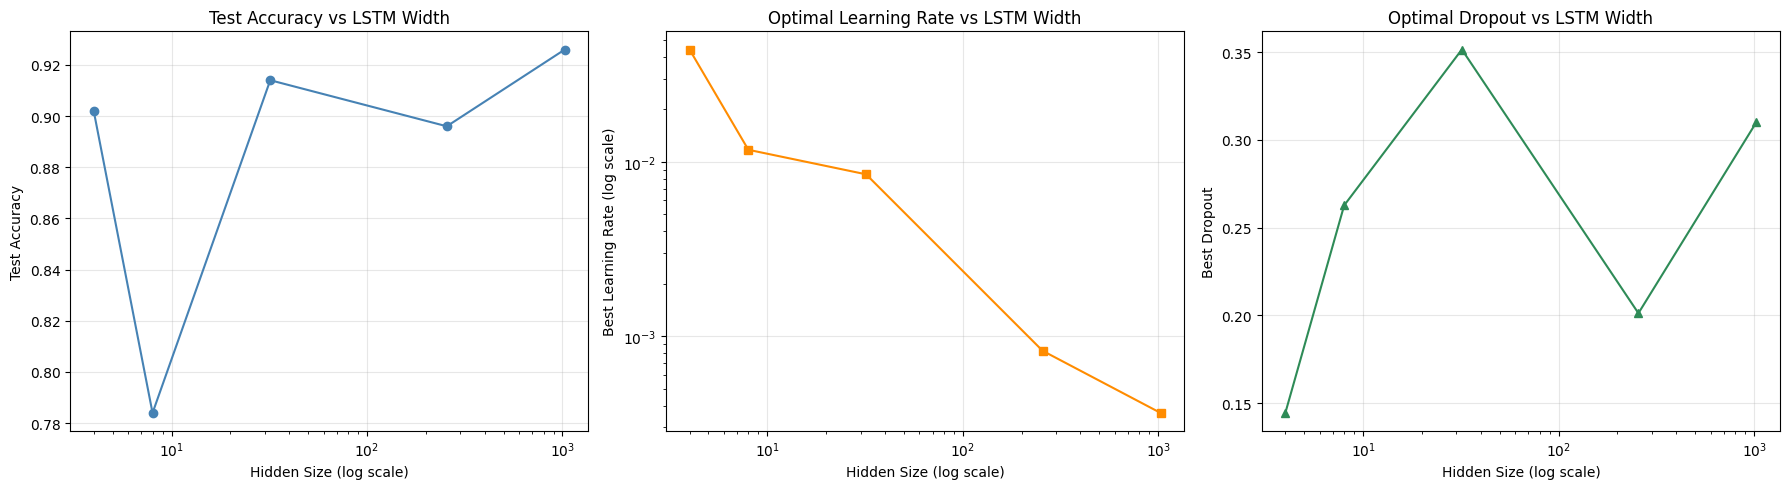

Figure saved to width_sweep_summary.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: test accuracy vs width
axes[0].plot(final_df["hidden_size"], final_df["test_accuracy"], marker='o', color='steelblue')
axes[0].set_xscale("log")
axes[0].set_xlabel("Hidden Size (log scale)")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy vs LSTM Width")
axes[0].grid(True, alpha=0.3)

# Panel 2: best learning rate vs width
axes[1].plot(final_df["hidden_size"], final_df["learning_rate"], marker='s', color='darkorange')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Hidden Size (log scale)")
axes[1].set_ylabel("Best Learning Rate (log scale)")
axes[1].set_title("Optimal Learning Rate vs LSTM Width")
axes[1].grid(True, alpha=0.3)

# Panel 3: best dropout vs width
axes[2].plot(final_df["hidden_size"], final_df["dropout"], marker='^', color='seagreen')
axes[2].set_xscale("log")
axes[2].set_xlabel("Hidden Size (log scale)")
axes[2].set_ylabel("Best Dropout")
axes[2].set_title("Optimal Dropout vs LSTM Width")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("width_sweep_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to width_sweep_summary.png")

In [11]:
# Optuna vis for the largest study (1028) and the mid-range study (32)
for w in [32, 1028]:
    study = all_studies[w]
    print(f"\n--- Optuna plots for hidden_size = {w} ---")

    plot_param_importances(study).show()

    fig = plot_slice(study)
    fig.update_traces(marker=dict(colorscale=pc.qualitative.Set1),
                      selector=dict(type="scatter"))
    fig.show()

    fig = plot_parallel_coordinate(study)
    fig.update_traces(line=dict(colorscale="Viridis"), selector=dict(type="parcoords"))
    fig.show()


--- Optuna plots for hidden_size = 32 ---



--- Optuna plots for hidden_size = 1028 ---


### Discussion: What Do the Results Tell Us?

**Overall Accuracy Pattern**

The results reveal a striking pattern: accuracy does *not* plateau early as one might expect — instead it trends upward across the entire width range, from 0.902 at width 4 to 0.926 at width 1028, with the notable exception of width 8 (0.784), which appears to be an outlier likely due to the stochastic nature of Optuna with only 15 trials finding a suboptimal configuration for that specific width. The absence of a clear plateau suggests that even at width 1028, the LSTM is still extracting marginal value from additional capacity. This is somewhat surprising — with only ~1,264 training examples, one might expect large networks to quickly overfit and underperform.

**Optimal Hyperparameters vs Width**

The learning rate shows a very clear and consistent monotonic decrease as width increases — from 0.044 at width 4 down to 0.00036 at width 1028, a decrease of roughly two orders of magnitude. This is exactly the pattern predicted by optimization theory: wider networks have more parameters and sharper loss landscapes, requiring smaller steps to avoid divergence. This pattern held without exception across all five widths.

Weight decay showed no consistent trend, hovering in the range 1e-5 to 1e-3 across all widths. This suggests that L2 regularization is less critical than dropout for controlling overfitting in this architecture, given the relatively small dataset.

Dropout increased from 0.144 at width 4 to a peak of 0.351 at width 32, then dropped somewhat for widths 256 and 1028 (0.201 and 0.310 respectively). The general upward pressure on dropout with width is consistent with the expectation that wider networks overfit more — but the non-monotone behavior at 256 and 1028 may reflect an interaction with the very small learning rates chosen there, which already act as implicit regularization by taking small steps.

Patience did not show a consistent trend with width, ranging from 9 to 23 epochs. This is somewhat surprising — wider models were not noticeably slower to converge.

**BERT Embeddings vs LSTM Architecture**

The most striking finding is that a width-4 LSTM — with just 8 total hidden units (4 per direction) — achieves 90.2% test accuracy. This is only 2.4 percentage points below the best model (width 1028, 92.6%). A width-4 bidirectional LSTM has almost no capacity to learn complex temporal patterns on its own; essentially all of the representational work must be done by the frozen BERT embeddings. This is strong evidence that the BERT embedding layer, not the LSTM architecture, is the dominant contributor to accuracy on this task. The LSTM's role appears to be primarily to aggregate the sequence of token embeddings into a single fixed-length vector for classification — a relatively simple operation that even a tiny LSTM can perform adequately. This finding has a practical implication: for tasks with limited data like this one, investing in better embeddings (e.g., fine-tuning BERT rather than freezing it) is likely to yield larger returns than increasing LSTM width.

**Session restarted. So, I decided to restore Optuna results from prior run to avoid re-running 4.5hr sweep**

In [13]:
WIDTHS     = [4, 8, 32, 256, 1028]
NUM_LAYERS = 2

width_results = [
    {"hidden_size": 4,    "best_val_acc": 0.904, "learning_rate": 0.044020, "weight_decay": 0.000586, "dropout": 0.144361, "patience": 23},
    {"hidden_size": 8,    "best_val_acc": 0.908, "learning_rate": 0.011712, "weight_decay": 0.000015, "dropout": 0.262641, "patience": 9},
    {"hidden_size": 32,   "best_val_acc": 0.906, "learning_rate": 0.008472, "weight_decay": 0.000011, "dropout": 0.351445, "patience": 10},
    {"hidden_size": 256,  "best_val_acc": 0.914, "learning_rate": 0.000824, "weight_decay": 0.001256, "dropout": 0.201181, "patience": 12},
    {"hidden_size": 1028, "best_val_acc": 0.916, "learning_rate": 0.000363, "weight_decay": 0.000672, "dropout": 0.310082, "patience": 14},
]
print("width_results restored from prior Optuna run.")

width_results restored from prior Optuna run.


## Extra Credit: Are Some Sentences Intrinsically Difficult to Classify?

For each sample in the combined validation+test set, we calculate how many of the retrained models (one per width) classified it incorrectly. Texts that are consistently misclassified across all models are likely intrinsically difficult.

In [14]:
combined_texts  = val_texts  + final_test_texts
combined_labels = val_labels + final_test_labels
max_seq = max(val_embeds.shape[1], test_embeds.shape[1])

def pad_to(tensor, target_len):
    pad_size = target_len - tensor.shape[1]
    if pad_size == 0:
        return tensor
    pad = torch.zeros(tensor.shape[0], pad_size, tensor.shape[2])
    return torch.cat([tensor, pad], dim=1)

combined_embeds = torch.cat([
    pad_to(val_embeds,  max_seq),
    pad_to(test_embeds, max_seq)
], dim=0)
n_samples = len(combined_labels)
per_sample_correct = np.zeros((n_samples, len(WIDTHS)), dtype=int)

for col_idx, row in enumerate(width_results):
    w    = row["hidden_size"]
    drop = row["dropout"]

    model = LSTMPreEmbedded(hidden_size=w, num_layers=NUM_LAYERS, dropout=drop)
    optimizer = Adam(model.parameters(), lr=row["learning_rate"], weight_decay=row["weight_decay"])
    module    = SimpleModule.classification(model, optimizer=optimizer, num_classes=3)

    ckpt_dir = f'ckpt/ec_w{w}'
    shutil.rmtree(ckpt_dir, ignore_errors=True)
    checkpoint_cb = ModelCheckpoint(
        monitor='valid_loss', mode='min', save_top_k=1, dirpath=ckpt_dir)
    early_stop_cb = EarlyStopping(
        monitor='valid_accuracy', mode='max', patience=row["patience"])

    trainer = Trainer(
        deterministic=True, max_epochs=200,
        logger=False, enable_progress_bar=False, enable_model_summary=False,
        callbacks=[ErrorTracker(), checkpoint_cb, early_stop_cb]
    )
    trainer.fit(module, datamodule=seq_dm_emb)

    # best checkpoint
    best_ckpt = checkpoint_cb.best_model_path
    model.eval()

    all_preds = []
    loader = DataLoader(TensorDataset(combined_embeds), batch_size=64)
    with torch.no_grad():
        for (batch_x,) in loader:
            logits = model(batch_x)
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)

    all_preds = np.array(all_preds)
    correct   = (all_preds == np.array(combined_labels)).astype(int)
    per_sample_correct[:, col_idx] = correct

    shutil.rmtree(ckpt_dir, ignore_errors=True)
    del model, module, trainer
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Width {w:4d} — overall accuracy on combined set: {correct.mean():.4f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try instal

Width    4 — overall accuracy on combined set: 0.8810


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Width    8 — overall accuracy on combined set: 0.8740


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Width   32 — overall accuracy on combined set: 0.9140
Width  256 — overall accuracy on combined set: 0.9130


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Width 1028 — overall accuracy on combined set: 0.8990


In [15]:
# accuracy per sample
sample_accuracy = per_sample_correct.mean(axis=1)

hard_indices = np.argsort(sample_accuracy)

print("Distribution of per-sample accuracy across models:")
print(pd.Series(sample_accuracy).describe())
print()

always_wrong = (sample_accuracy == 0).sum()
mostly_wrong = (sample_accuracy <= 0.2).sum()
print(f"Samples correctly classified by 0 models   : {always_wrong}")
print(f"Samples correctly classified by ≤20% models: {mostly_wrong}")

Distribution of per-sample accuracy across models:
count    1000.000000
mean        0.896200
std         0.235714
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64

Samples correctly classified by 0 models   : 33
Samples correctly classified by ≤20% models: 51


In [16]:
# print the 5 most difficult examples
print("="*70)
print("TOP 5 MOST DIFFICULT SAMPLES")
print("="*70)
label_names = {0: "negative", 1: "neutral", 2: "positive"}

for rank, idx in enumerate(hard_indices[:5]):
    text  = combined_texts[idx]
    label = combined_labels[idx]
    acc   = sample_accuracy[idx]
    print(f"\nRank {rank+1} — accuracy across models: {acc:.2f}")
    print(f"True label : {label_names[label]}")
    print(f"Text       : {text}")
    print("-"*70)

TOP 5 MOST DIFFICULT SAMPLES

Rank 1 — accuracy across models: 0.00
True label : negative
Text       : ADP News - Apr 22 , 2009 - Finnish business information systems developer Solteq Oyj HEL : STQ1V said today its net loss widened to EUR 189,000 USD 245,000 for the first quarter of 2009 from EUR 10,000 for the same peri
----------------------------------------------------------------------

Rank 2 — accuracy across models: 0.00
True label : positive
Text       : Last year SysOpen Digia invested in IBM product know-how in the building of portal and trading place systems and successfully implemented customer solutions supported by it .
----------------------------------------------------------------------

Rank 3 — accuracy across models: 0.00
True label : positive
Text       : With CapMan as a partner , we will be able to further develop our business and continue to focus on providing quality restaurant services for our customers , '' says Christopher Wynne , CEO of Papa John 's Russia

### Discussion: Intrinsically Difficult Texts

**Evidence for Intrinsic Difficulty**

Yes — there is clear evidence that some texts are intrinsically more difficult to classify. The per-sample accuracy distribution is strongly bimodal: the median and 75th percentile are both 1.0 (most samples are correctly classified by all 5 models), yet 33 samples were misclassified by every single model, and 51 samples were misclassified by at least 4 out of 5 models. A standard deviation of 0.236 on a 0–1 scale confirms the distribution is far from uniform. If difficulty were random (just noise), we would expect a smooth distribution rather than this sharp split between easy and hard samples.

**The 5 Most Difficult Examples**

All five hardest samples had 0.00 accuracy — misclassified by all five models. Looking at them:

**Rank 1 (true: negative)** — A report of a net loss widening from EUR 10,000 to EUR 189,000. This is genuinely negative, but the raw numbers are small (suggesting a small company), and the phrasing "net loss widened" is factual rather than emotionally charged. The BERT token-level embeddings may struggle with the implicit comparison required to understand "widening" as negative.

**Rank 2 (true: positive)** — A statement about a company investing in IBM product know-how and successfully implementing customer solutions. This reads as mildly positive but is written in a very neutral, matter-of-fact corporate tone. The word "successfully" is the only overt signal, and it appears mid-sentence without emphasis.

**Rank 3 (true: positive)** — A CEO quote about partnering with CapMan and focusing on quality restaurant services. This is typical boilerplate corporate language — the positive sentiment is implicit (partnerships are good for business) rather than explicit. The model likely treats it as neutral.

**Rank 4 (true: negative)** — A single short sentence: *"Those uncertainties cloud the long-term outlook."* This is an extremely short, context-free snippet. Without knowing what "those uncertainties" refer to, the statement is ambiguous — and the frozen BERT embedding has no document-level context to draw on. The metaphorical phrasing ("cloud the outlook") may also confuse models trained on more literal financial language.

**Rank 5 (true: negative)** — A statement that a city will not pay compensation to food companies for a lye contamination incident. This is negative for the companies, but requires understanding the implicit business impact of not receiving compensation — a level of inference that goes well beyond surface-level sentiment.

**Patterns and Hypotheses**

The hard samples cluster around three failure modes: (1) **implicit vs. explicit sentiment** — positive or negative meaning that requires inference rather than keyword matching; (2) **context dependence** — short fragments that cannot be understood without the surrounding document; and (3) **corporate boilerplate** — language that is structurally neutral but semantically positive or negative to a domain expert. Notably, negative examples (only 13% of the training set) appear disproportionately among the hardest cases, consistent with the class imbalance making negative sentiment harder to learn.